In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# Dummy dataset
X = torch.randn(1000, 20)
y = torch.randn(1000, 1)


1. Create a simple Deep Neural Network (10 layers)

In [ ]:
class DeepNN(nn.Module):
    def __init__(self, activation='sigmoid', weight_scale=0.01, symmetry=False):
        super().__init__()
        layers = []
        input_dim = 20

        for _ in range(9):   # 9 hidden layers
            fc = nn.Linear(input_dim, 50)

            # Symmetry problem (same weights)
            if symmetry:
                nn.init.constant_(fc.weight, 0.5)
                nn.init.constant_(fc.bias, 0.0)
            else:
                nn.init.normal_(fc.weight, 0.0, weight_scale)
                nn.init.zeros_(fc.bias)

            layers.append(fc)
            layers.append(nn.Sigmoid() if activation == 'sigmoid' else nn.Tanh())
            input_dim = 50

        layers.append(nn.Linear(50, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


Vanishing Gradient Demonstration

In [ ]:
def vanishing_gradient(activation):
    model = DeepNN(activation=activation, weight_scale=0.01)
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()

    grad_norms = []

    for epoch in range(20):
        optimizer.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()

        grad = sum(p.grad.norm().item() for p in model.parameters() if p.grad is not None)
        grad_norms.append(grad)
        optimizer.step()

    return grad_norms


Plot gradient behavior

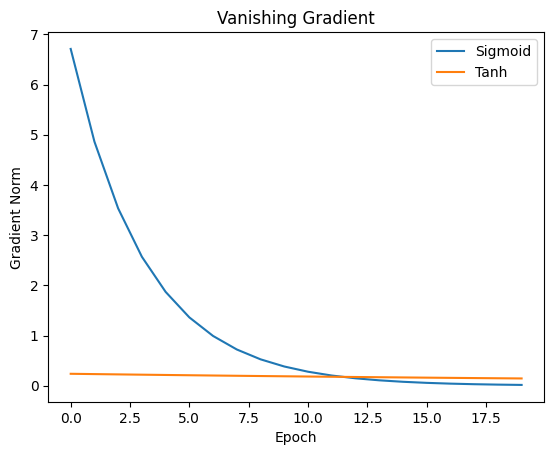

In [ ]:
vg_sigmoid = vanishing_gradient('sigmoid')
vg_tanh = vanishing_gradient('tanh')

plt.plot(vg_sigmoid, label='Sigmoid')
plt.plot(vg_tanh, label='Tanh')
plt.title("Vanishing Gradient")
plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.legend()
plt.show()



Exploding Gradient Demonstration

In [ ]:
def exploding_gradient(activation):
    model = DeepNN(activation=activation, weight_scale=1.5)
    optimizer = optim.SGD(model.parameters(), lr=0.1)
    loss_fn = nn.MSELoss()

    grad_norms = []

    for epoch in range(20):
        optimizer.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()

        grad = sum(p.grad.norm().item() for p in model.parameters() if p.grad is not None)
        grad_norms.append(grad)
        optimizer.step()

    return grad_norms


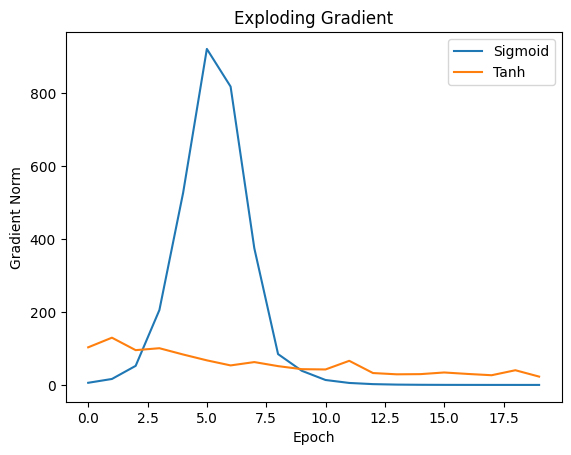

In [ ]:
eg_sigmoid = exploding_gradient('sigmoid')
eg_tanh = exploding_gradient('tanh')

plt.plot(eg_sigmoid, label='Sigmoid')
plt.plot(eg_tanh, label='Tanh')
plt.title("Exploding Gradient")
plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.legend()
plt.show()


3. Symmetry Problem Demonstration

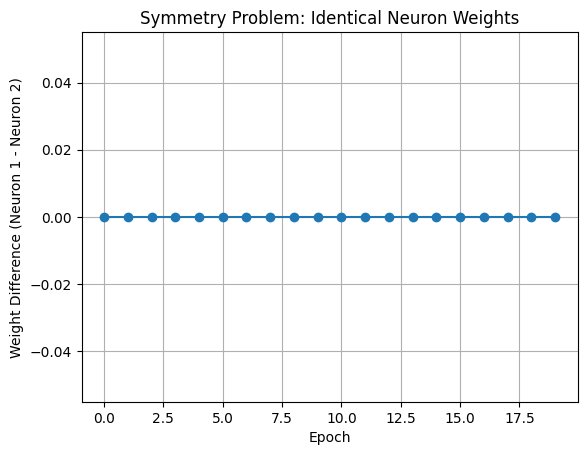

In [ ]:

# Symmetric model
model_sym = DeepNN(activation='sigmoid', symmetry=True)

criterion = nn.MSELoss()
optimizer = optim.SGD(model_sym.parameters(), lr=0.01)

weight_diff = []

# Training loop
for epoch in range(20):
    optimizer.zero_grad()
    loss = criterion(model_sym(X), y)
    loss.backward()
    optimizer.step()

    # Get weights of first layer
    w = model_sym.net[0].weight

    # L2 norm of difference between neuron 0 and 1
    diff = torch.norm(w[0] - w[1]).item()
    weight_diff.append(diff)

# Plot
plt.plot(weight_diff, marker='o')
plt.title("Symmetry Problem: Identical Neuron Weights")
plt.xlabel("Epoch")
plt.ylabel("Weight Difference (Neuron 1 - Neuron 2)")
plt.grid(True)
plt.show()


4. Weight Initialization Strategies

(a) Xavier Initialization

In [ ]:
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)


In [ ]:
def xavier_gradient(activation):
    model = DeepNN(activation=activation)
    model.apply(xavier_init)

    optimizer = optim.SGD(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()

    grad_norms = []

    for epoch in range(20):
        optimizer.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()

        grad = sum(p.grad.norm().item() for p in model.parameters() if p.grad is not None)
        grad_norms.append(grad)
        optimizer.step()

    return grad_norms


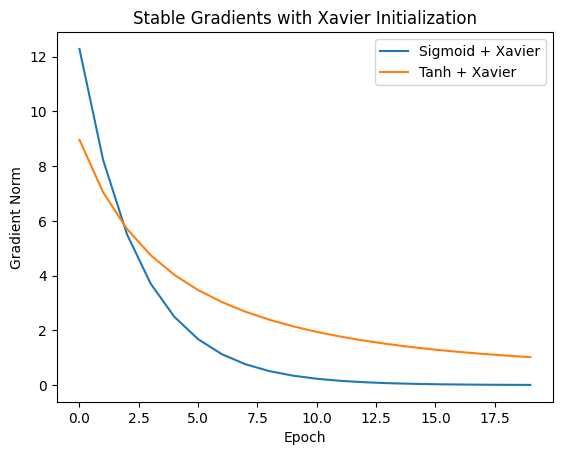

In [ ]:
xg_sigmoid = xavier_gradient('sigmoid')
xg_tanh = xavier_gradient('tanh')

plt.plot(xg_sigmoid, label='Sigmoid + Xavier')
plt.plot(xg_tanh, label='Tanh + Xavier')
plt.title("Stable Gradients with Xavier Initialization")
plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.legend()
plt.show()


(b) He Initialization

In [ ]:
def he_init(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        nn.init.zeros_(m.bias)


In [ ]:
def he_gradient(activation):
    model = DeepNN(activation=activation)
    model.apply(he_init)

    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    grad_norms = []

    for epoch in range(20):
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()

        grad = sum(p.grad.norm().item()
                   for p in model.parameters() if p.grad is not None)
        grad_norms.append(grad)
        optimizer.step()

    return grad_norms


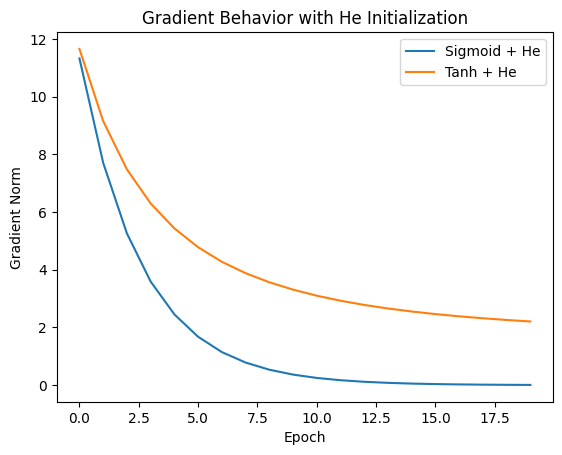

In [ ]:
hg_sigmoid = he_gradient('sigmoid')
hg_tanh = he_gradient('tanh')

plt.plot(hg_sigmoid, label='Sigmoid + He')
plt.plot(hg_tanh, label='Tanh + He')
plt.title("Gradient Behavior with He Initialization")
plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.legend()
plt.show()
